# **Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# **Phase 1**

---



### **Loads student-mat.csv**

In [2]:
df = pd.read_csv("D:/3rd Semester/Real World Analytics/Assignment/Data analyse project/student-academic-performance-analysis/data/student-mat.csv", sep=';')
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


### **Keep only important columns**

In [3]:
important_cols = [
    "sex", "age",                     # demographic (optional)
    "absences", "goout", "freetime", "Dalc", "Walc","health",  # behavioral
    "famsup", "schoolsup", "internet", # socioeconomic
    "failures", "studytime","G1", "G2",          # academic
    "G3"                                         # target
]

df = df[important_cols].copy()
print("After column selection:", df.shape)
df


After column selection: (395, 16)


,sex,age,absences,goout,freetime,Dalc,Walc,health,famsup,schoolsup,internet,failures,studytime,G1,G2,G3
0,F,18,6,4,3,1,1,3,no,yes,no,0,2,5,6,6
1,F,17,4,3,3,1,1,3,yes,no,yes,0,2,5,5,6
2,F,15,10,2,3,2,3,3,no,yes,yes,3,2,7,8,10
3,F,15,2,2,2,1,1,5,yes,no,yes,0,3,15,14,15
4,F,16,4,2,3,1,2,5,yes,no,no,0,2,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,M,20,11,4,5,4,5,4,yes,no,no,2,2,9,9,9
391,M,17,3,5,4,3,4,2,no,no,yes,0,1,14,16,16
392,M,21,3,3,5,3,3,3,no,no,no,3,1,10,8,7
393,M,18,0,1,4,3,4,5,no,no,yes,0,1,11,12,10


### **Check Data Types (before encoding)**

In [4]:
df.dtypes

sex            str
age          int64
absences     int64
goout        int64
freetime     int64
Dalc         int64
Walc         int64
health       int64
famsup         str
schoolsup      str
internet       str
failures     int64
studytime    int64
G1           int64
G2           int64
G3           int64
dtype: object

### **Encode categorical variables**

In [5]:
binary_map = {"yes": 1, "no": 0}
df["famsup"]    = df["famsup"].map(binary_map)
df["schoolsup"] = df["schoolsup"].map(binary_map)
df["internet"]  = df["internet"].map(binary_map)

sex_map = {"F": 0, "M": 1}
df["sex"] = df["sex"].map(sex_map)

df.head()


,sex,age,absences,goout,freetime,Dalc,Walc,health,famsup,schoolsup,internet,failures,studytime,G1,G2,G3
0,0,18,6,4,3,1,1,3,0,1,0,0,2,5,6,6
1,0,17,4,3,3,1,1,3,1,0,1,0,2,5,5,6
2,0,15,10,2,3,2,3,3,0,1,1,3,2,7,8,10
3,0,15,2,2,2,1,1,5,1,0,1,0,3,15,14,15
4,0,16,4,2,3,1,2,5,1,0,0,0,2,6,10,10


### **Check Data Types (after encoding)**

In [6]:
df.dtypes

sex          int64
age          int64
absences     int64
goout        int64
freetime     int64
Dalc         int64
Walc         int64
health       int64
famsup       int64
schoolsup    int64
internet     int64
failures     int64
studytime    int64
G1           int64
G2           int64
G3           int64
dtype: object

### **Check missing values**

In [7]:
df.isna().sum()

sex          0
age          0
absences     0
goout        0
freetime     0
Dalc         0
Walc         0
health       0
famsup       0
schoolsup    0
internet     0
failures     0
studytime    0
G1           0
G2           0
G3           0
dtype: int64

### **Handle Duplicates**

In [8]:
print("Duplicates before cleaning:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after cleaning:", df.duplicated().sum())
df

Duplicates before cleaning: 0
Duplicates after cleaning: 0


,sex,age,absences,goout,freetime,Dalc,Walc,health,famsup,schoolsup,internet,failures,studytime,G1,G2,G3
0,0,18,6,4,3,1,1,3,0,1,0,0,2,5,6,6
1,0,17,4,3,3,1,1,3,1,0,1,0,2,5,5,6
2,0,15,10,2,3,2,3,3,0,1,1,3,2,7,8,10
3,0,15,2,2,2,1,1,5,1,0,1,0,3,15,14,15
4,0,16,4,2,3,1,2,5,1,0,0,0,2,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,20,11,4,5,4,5,4,1,0,0,2,2,9,9,9
391,1,17,3,5,4,3,4,2,0,0,1,0,1,14,16,16
392,1,21,3,3,5,3,3,3,0,0,0,3,1,10,8,7
393,1,18,0,1,4,3,4,5,0,0,1,0,1,11,12,10


### **Outlier Visualization (Boxplots)**

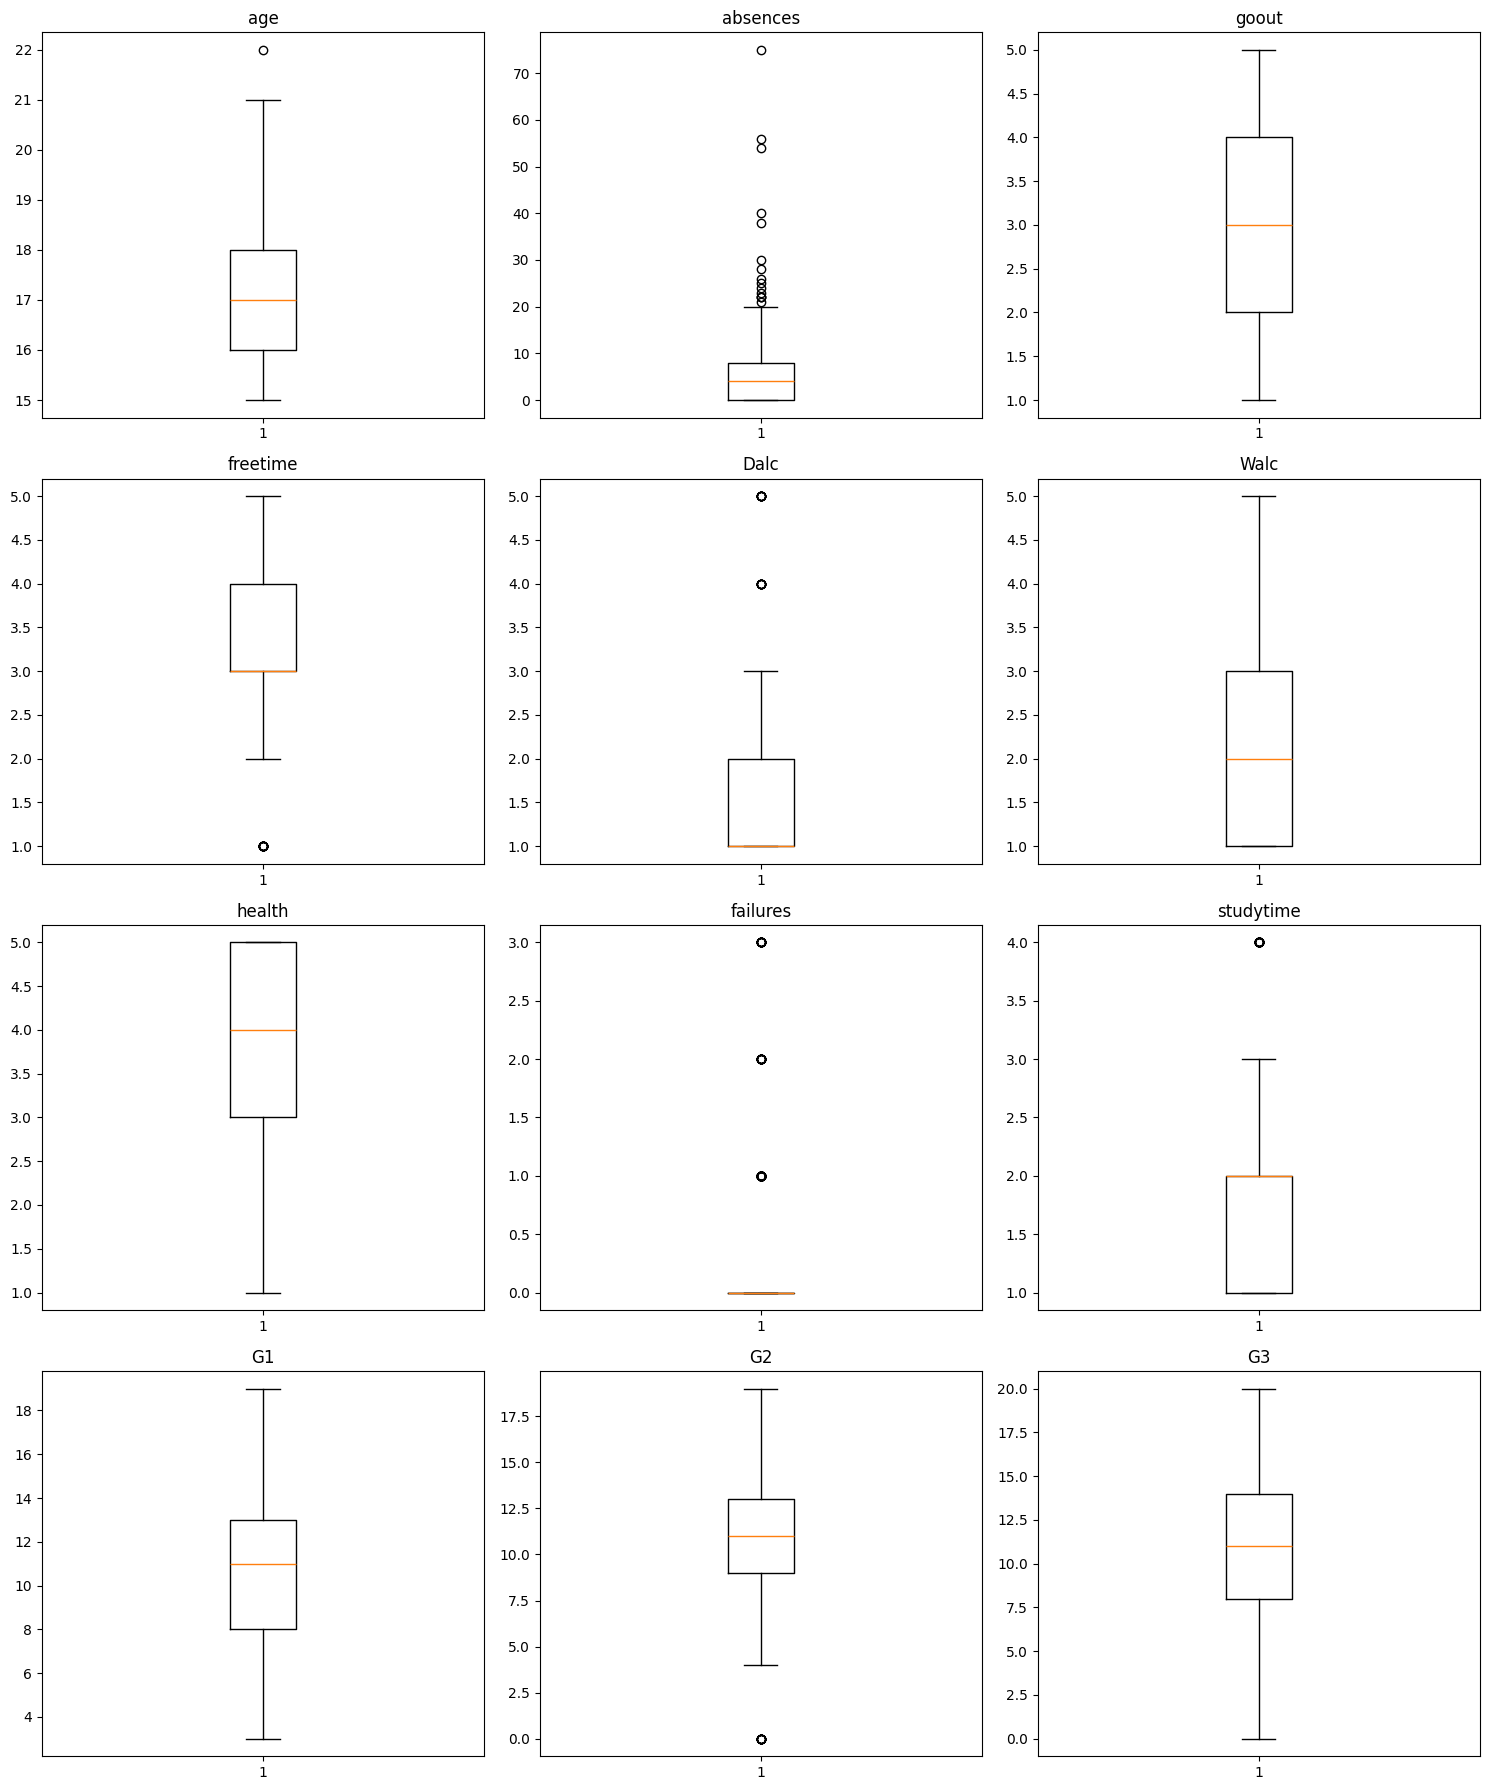

In [9]:
num_cols = [
    "age", "absences", "goout", "freetime", "Dalc",
    "Walc", "health", "failures", "studytime",
    "G1", "G2", "G3"
]

plt.figure(figsize=(15, 18))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()


### **Outlier Detection & Removal (IQR)**



In [10]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower) & (df[column] <= upper)]
    return df

numeric_cols = ["age", "absences", "goout", "freetime", "Dalc", "Walc",
                "health", "failures", "studytime", "G1", "G2", "G3"]

for col in numeric_cols:
    df = remove_outliers(df, col)

df = df.reset_index(drop=True)
print("Dataset shape after outlier removal:", df.shape)
df

Dataset shape after outlier removal: (263, 16)


,sex,age,absences,goout,freetime,Dalc,Walc,health,famsup,schoolsup,internet,failures,studytime,G1,G2,G3
0,0,18,6,4,3,1,1,3,0,1,0,0,2,5,6,6
1,0,17,4,3,3,1,1,3,1,0,1,0,2,5,5,6
2,0,15,2,2,2,1,1,5,1,0,1,0,3,15,14,15
3,0,16,4,2,3,1,2,5,1,0,0,0,2,6,10,10
4,1,16,10,2,4,1,2,5,1,0,1,0,2,15,15,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,0,18,7,3,4,2,2,5,1,0,1,0,1,6,5,6
259,0,18,0,4,3,1,1,1,1,0,1,0,2,7,9,8
260,1,17,3,5,4,3,4,2,0,0,1,0,1,14,16,16
261,1,18,0,1,4,3,4,5,0,0,1,0,1,11,12,10


### **Summary Statistics (cleaned data)**

In [11]:
df.describe()

,sex,age,absences,goout,freetime,Dalc,Walc,health,famsup,schoolsup,internet,failures,studytime,G1,G2,G3
count,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.0,263.000000,263.000000,263.000000,263.000000
mean,0.467681,16.456274,4.311787,3.015209,3.288973,1.281369,2.106464,3.490494,0.631179,0.117871,0.851711,0.0,2.106464,11.809886,11.916350,12.121673
std,0.499906,1.110751,4.424271,1.051969,0.869408,0.570184,1.140877,1.435278,0.483405,0.323070,0.356064,0.0,0.853862,3.109021,3.086637,3.159927
min,0.000000,15.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,1.000000,5.000000,5.000000,5.000000
25%,0.000000,16.000000,0.000000,2.000000,3.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.0,2.000000,10.000000,10.000000,10.000000
50%,0.000000,16.000000,3.000000,3.000000,3.000000,1.000000,2.000000,4.000000,1.000000,0.000000,1.000000,0.0,2.000000,12.000000,12.000000,12.000000
75%,1.000000,17.000000,6.000000,4.000000,4.000000,1.000000,3.000000,5.000000,1.000000,0.000000,1.000000,0.0,3.000000,14.000000,14.000000,15.000000
max,1.000000,20.000000,20.000000,5.000000,5.000000,3.000000,5.000000,5.000000,1.000000,1.000000,1.000000,0.0,4.000000,19.000000,19.000000,20.000000


### **Correlation Matrix**

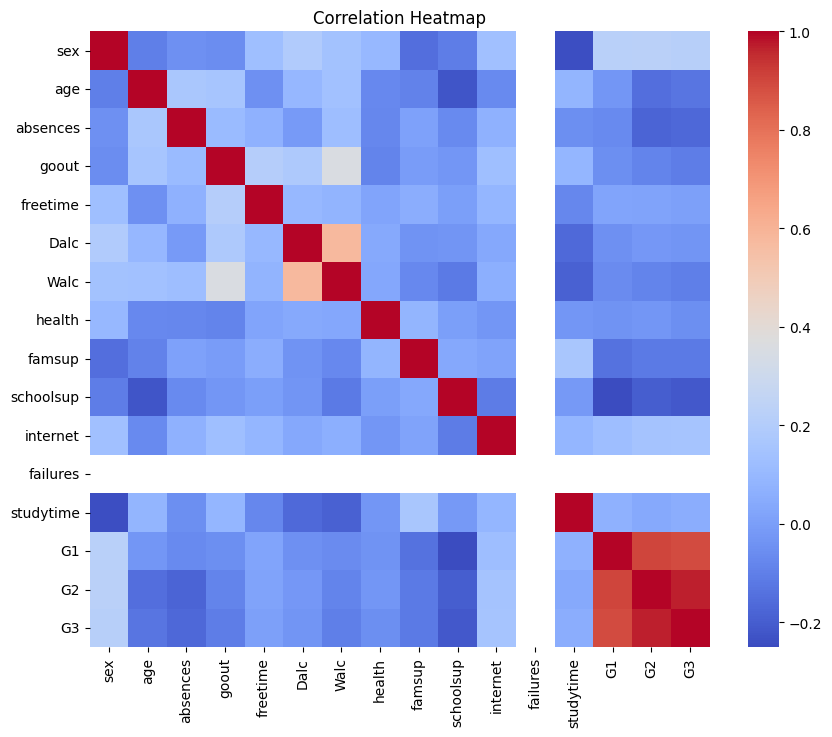

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### **Standardization**

In [13]:
df = df.copy()

scale_cols = [
    "age", "absences", "goout", "freetime", "Dalc",
    "Walc", "health", "failures", "studytime",
    "G1", "G2"
]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

df

,sex,age,absences,goout,freetime,Dalc,Walc,health,famsup,schoolsup,internet,failures,studytime,G1,G2,G3
0,0,1.392454,0.382307,0.937926,-0.333013,-0.494411,-0.971686,-0.342393,0,1,0,0.0,-0.124923,-2.194540,-1.920417,6
1,0,0.490446,-0.070606,-0.014485,-0.333013,-0.494411,-0.971686,-0.342393,1,0,1,0.0,-0.124923,-2.194540,-2.245012,6
2,0,-1.313571,-0.523520,-0.966896,-1.485414,-0.494411,-0.971686,1.053722,1,0,1,0.0,1.048460,1.028040,0.676342,15
3,0,-0.411563,-0.070606,-0.966896,-0.333013,-0.494411,-0.093496,1.053722,1,0,0,0.0,-0.124923,-1.872282,-0.622037,10
4,1,-0.411563,1.288135,-0.966896,0.819388,-0.494411,-0.093496,1.053722,1,0,1,0.0,-0.124923,1.028040,1.000937,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,0,1.392454,0.608764,-0.014485,0.819388,1.262753,-0.093496,1.053722,1,0,1,0.0,-1.298305,-1.872282,-2.245012,6
259,0,1.392454,-0.976434,0.937926,-0.333013,-0.494411,-0.971686,-1.738508,1,0,1,0.0,-0.124923,-1.550024,-0.946632,8
260,1,0.490446,-0.297063,1.890337,0.819388,3.019917,1.662885,-1.040451,0,0,1,0.0,-1.298305,0.705782,1.325532,16
261,1,1.392454,-0.976434,-1.919307,0.819388,3.019917,1.662885,1.053722,0,0,1,0.0,-1.298305,-0.260992,0.027152,10


# **Phase 2**

---

### **Feature Engineering**

In [14]:
df = df.copy()

df["avg_grade"] = (df["G1"] + df["G2"]) / 2

df["alcohol_total"] = df["Dalc"] + df["Walc"]

df["study_efficiency"] = df["studytime"] / (df["goout"] + 1e-6)

df


,sex,age,absences,goout,freetime,Dalc,Walc,health,famsup,schoolsup,internet,failures,studytime,G1,G2,G3,avg_grade,alcohol_total,study_efficiency
0,0,1.392454,0.382307,0.937926,-0.333013,-0.494411,-0.971686,-0.342393,0,1,0,0.0,-0.124923,-2.194540,-1.920417,6,-2.057478,-1.466097,-0.133190
1,0,0.490446,-0.070606,-0.014485,-0.333013,-0.494411,-0.971686,-0.342393,1,0,1,0.0,-0.124923,-2.194540,-2.245012,6,-2.219776,-1.466097,8.624684
2,0,-1.313571,-0.523520,-0.966896,-1.485414,-0.494411,-0.971686,1.053722,1,0,1,0.0,1.048460,1.028040,0.676342,15,0.852191,-1.466097,-1.084357
3,0,-0.411563,-0.070606,-0.966896,-0.333013,-0.494411,-0.093496,1.053722,1,0,0,0.0,-0.124923,-1.872282,-0.622037,10,-1.247160,-0.587907,0.129200
4,1,-0.411563,1.288135,-0.966896,0.819388,-0.494411,-0.093496,1.053722,1,0,1,0.0,-0.124923,1.028040,1.000937,15,1.014488,-0.587907,0.129200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,0,1.392454,0.608764,-0.014485,0.819388,1.262753,-0.093496,1.053722,1,0,1,0.0,-1.298305,-1.872282,-2.245012,6,-2.058647,1.169257,89.635104
259,0,1.392454,-0.976434,0.937926,-0.333013,-0.494411,-0.971686,-1.738508,1,0,1,0.0,-0.124923,-1.550024,-0.946632,8,-1.248328,-1.466097,-0.133190
260,1,0.490446,-0.297063,1.890337,0.819388,3.019917,1.662885,-1.040451,0,0,1,0.0,-1.298305,0.705782,1.325532,16,1.015657,4.682802,-0.686811
261,1,1.392454,-0.976434,-1.919307,0.819388,3.019917,1.662885,1.053722,0,0,1,0.0,-1.298305,-0.260992,0.027152,10,-0.116920,4.682802,0.676445


### **Define Features (X) and Target (y) + Train/Test Split**

In [15]:
y = df["G3"]

X = df.drop(columns=["G3"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((210, 18), (53, 18))

### **Helper Function to Evaluate Models**

In [16]:
results = []

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test,  y_test_pred)

    test_mse  = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)

    print(f"--- {name} ---")
    print("Train R² :", round(train_r2, 3))
    print("Test  R² :", round(test_r2, 3))
    print("Test MSE :", round(test_mse, 3))
    print("Test RMSE:", round(test_rmse, 3))
    print()

    results.append({
        "Model": name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Test_MSE": test_mse,
        "Test_RMSE": test_rmse
    })

## **Train the 4 Models**

### **Linear Regression**

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

evaluate_model("Linear Regression", lr, X_train, y_train, X_test, y_test)

--- Linear Regression ---
Train R² : 0.933
Test  R² : 0.95
Test MSE : 0.628
Test RMSE: 0.792



### **Ridge Regression (with a chosen alpha)**

In [18]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)

evaluate_model("Ridge Regression (α=1.0)", ridge, X_train, y_train, X_test, y_test)

--- Ridge Regression (α=1.0) ---
Train R² : 0.933
Test  R² : 0.95
Test MSE : 0.624
Test RMSE: 0.79



### **Lasso Regression**

In [19]:
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train, y_train)

evaluate_model("Lasso Regression (α=0.01)", lasso, X_train, y_train, X_test, y_test)

--- Lasso Regression (α=0.01) ---
Train R² : 0.933
Test  R² : 0.951
Test MSE : 0.616
Test RMSE: 0.785



### **Decision Tree Regressor (basic)**

In [20]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

evaluate_model("Decision Tree (no depth limit)", dt, X_train, y_train, X_test, y_test)

--- Decision Tree (no depth limit) ---
Train R² : 1.0
Test  R² : 0.892
Test MSE : 1.358
Test RMSE: 1.166



### **Model Comparison Table**

In [21]:
results_df = pd.DataFrame(results)
results_df

,Model,Train_R2,Test_R2,Test_MSE,Test_RMSE
0,Linear Regression,0.933156,0.950097,0.627764,0.792315
1,Ridge Regression (α=1.0),0.933056,0.950411,0.623808,0.789815
2,Lasso Regression (α=0.01),0.932850,0.951008,0.616295,0.785045
3,Decision Tree (no depth limit),1.000000,0.892008,1.358491,1.165543


### **Overfitting vs Underfitting (Decision Tree Depth)**

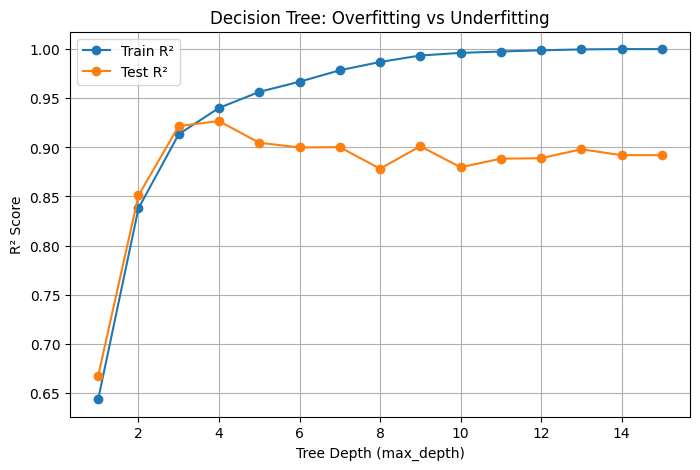

In [22]:
train_scores = []
test_scores = []
depths = range(1, 16)  # depths 1 to 15

for d in depths:
    dt_tmp = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_tmp.fit(X_train, y_train)

    y_train_pred = dt_tmp.predict(X_train)
    y_test_pred  = dt_tmp.predict(X_test)

    train_scores.append(r2_score(y_train, y_train_pred))
    test_scores.append(r2_score(y_test, y_test_pred))

# Plot
plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, marker='o', label="Train R²")
plt.plot(depths, test_scores, marker='o', label="Test R²")
plt.xlabel("Tree Depth (max_depth)")
plt.ylabel("R² Score")
plt.title("Decision Tree: Overfitting vs Underfitting")
plt.legend()
plt.grid(True)
plt.show()

# **Phase 3**

---

## **Re-evaluate the Best Model (Regression Metrics)**

In [23]:
# We’ll clearly compute the final evaluation metrics for the best model (Lasso).

# Predictions from best model (Lasso)
y_train_pred = lasso.predict(X_train)
y_test_pred  = lasso.predict(X_test)

# Metrics
train_r2  = r2_score(y_train, y_train_pred)
test_r2   = r2_score(y_test, y_test_pred)
test_mse  = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae  = mean_absolute_error(y_test, y_test_pred)

print("Best Model: Lasso Regression (α=0.01)")
print("Train R² :", round(train_r2, 3))
print("Test  R² :", round(test_r2, 3))
print("Test MSE :", round(test_mse, 3))
print("Test RMSE:", round(test_rmse, 3))
print("Test MAE :", round(test_mae, 3))


Best Model: Lasso Regression (α=0.01)
Train R² : 0.933
Test  R² : 0.951
Test MSE : 0.616
Test RMSE: 0.785
Test MAE : 0.609


## **Analyze Feature Importance in the Best Model**

In [24]:
# Get coefficients + feature names
coef = lasso.coef_
features = X_train.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef
}).sort_values(by="Coefficient", ascending=False)

display(importance_df)

,Feature,Coefficient
14,G2,2.739538
13,G1,0.221126
12,studytime,0.059408
15,avg_grade,0.057595
1,age,0.032285
5,Dalc,0.024558
17,study_efficiency,0.000780
0,sex,-0.000000
11,failures,0.000000
8,famsup,0.000000


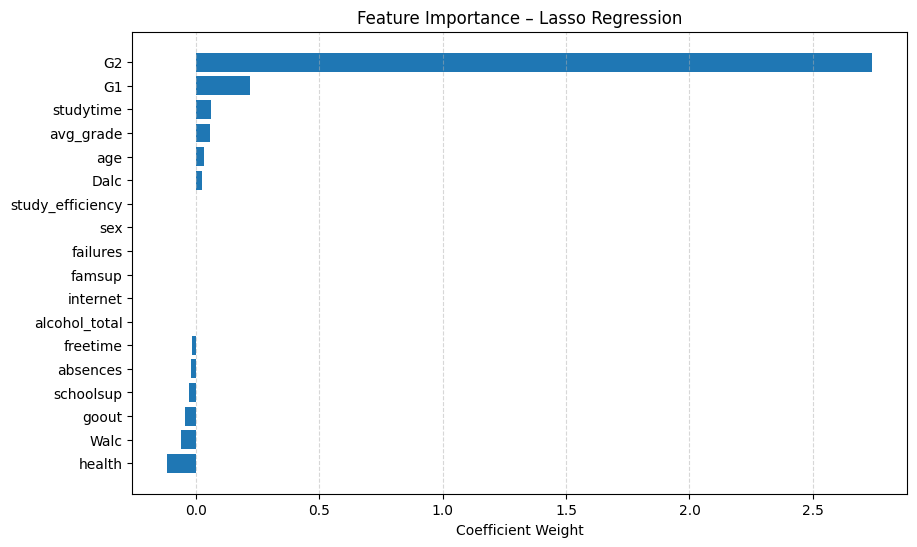

In [25]:
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Coefficient"])
plt.xlabel("Coefficient Weight")
plt.title("Feature Importance – Lasso Regression")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()

## **SHAP Analysis**

### **Build explainer for the Lasso model**

In [26]:
import shap

# Create SHAP explainer for linear model
explainer = shap.Explainer(lasso, X_train)
shap_values = explainer(X_test)   # SHAP values for test set

c:\Users\malsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 210 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=210 when initializing the masker.


### **SHAP summary bar plot**

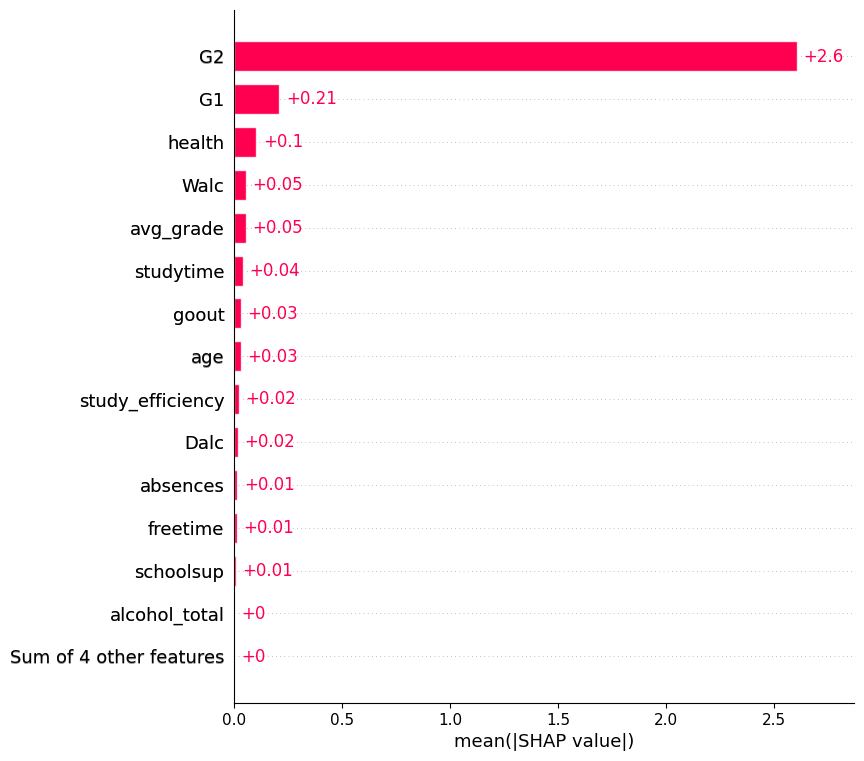

In [27]:
shap.plots.bar(shap_values, max_display=15)

### **SHAP beeswarm plot**

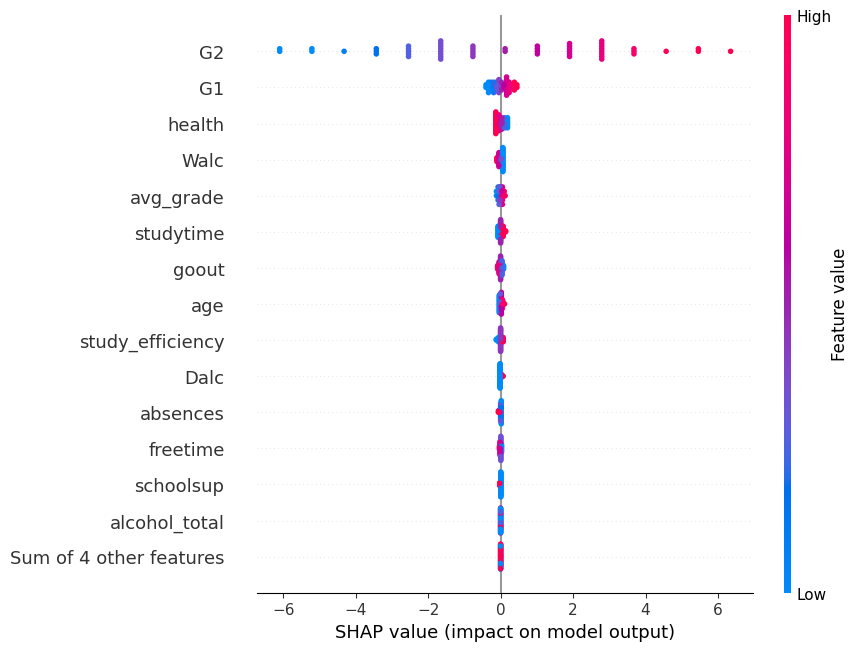

In [29]:
shap.plots.beeswarm(shap_values, max_display=15)

## **Explain Individual Predictions with SHAP**

True G3: 14
Predicted G3: 14.278565547386446


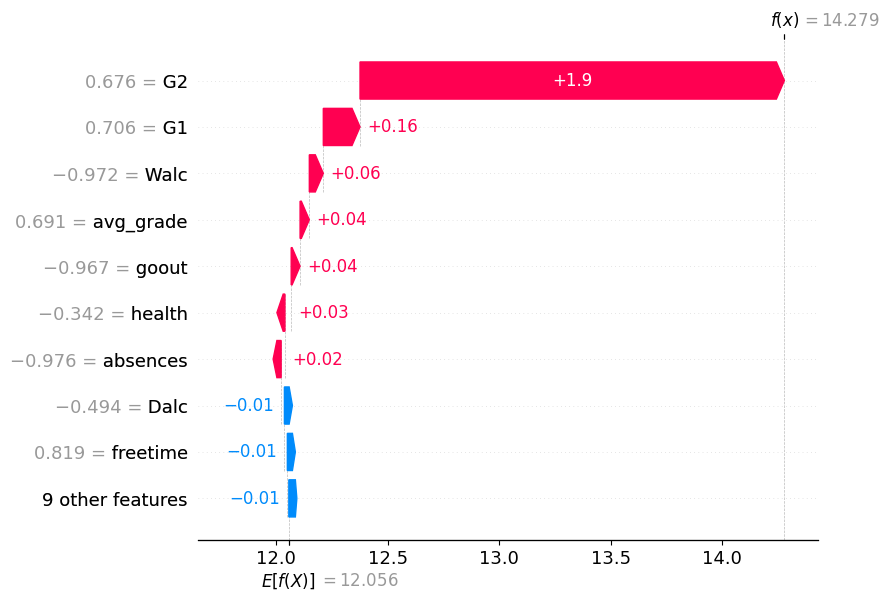

In [30]:
i = 0   # choose any index within range(len(X_test))

print("True G3:", y_test.iloc[i])
print("Predicted G3:", y_test_pred[i])

shap.plots.waterfall(shap_values[i])


## **Visual Error Analysis (Regression Equivalent of Confusion Matrix/ROC)**

### **Actual vs Predicted Plot**

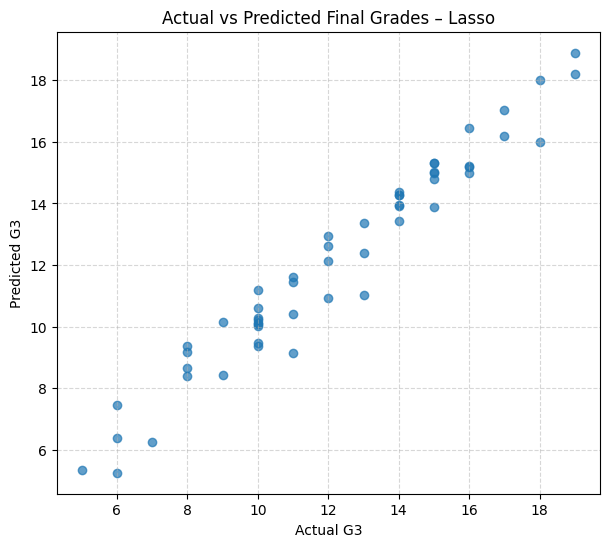

In [31]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grades – Lasso")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **Residual Plot (error vs prediction)**

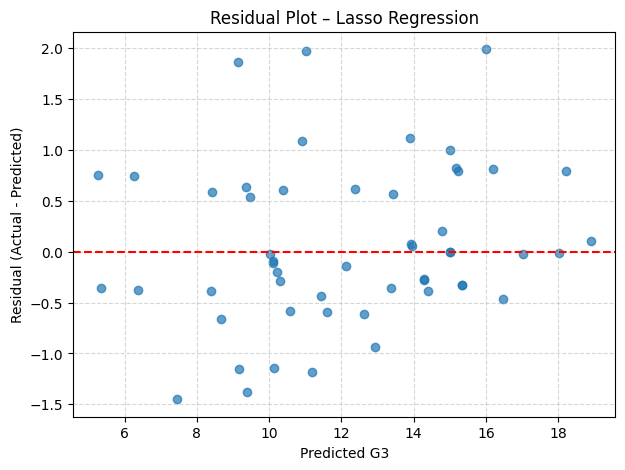

In [32]:
residuals = y_test - y_test_pred

plt.figure(figsize=(7,5))
plt.scatter(y_test_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted G3")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot – Lasso Regression")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **Reflect on Bias–Variance Trade-off**

In [33]:
results_df

,Model,Train_R2,Test_R2,Test_MSE,Test_RMSE
0,Linear Regression,0.933156,0.950097,0.627764,0.792315
1,Ridge Regression (α=1.0),0.933056,0.950411,0.623808,0.789815
2,Lasso Regression (α=0.01),0.932850,0.951008,0.616295,0.785045
3,Decision Tree (no depth limit),1.000000,0.892008,1.358491,1.165543
